Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you :
- Fill in your name
- Fill any place that says `YOUR CODE HERE` (you will be graded based on this code, any extra cells you code will not be graded)
- Delete  `NotImplementedError()` exception once you have completed your implementation

In [107]:
NAME = "NGUYEN THI THU TRANG"

In [108]:
import pytest

---

# **Problem 1: Object-Oriented Programming (3)**  

Implement a class hierarchy that models different types of employees in a company.  

### **1. Abstract Class Employee (Given below)**  
- **Attributes** (nonpublic):  
  - `name`: Employee’s name (**string data type only**).  
  - `employee_id`: Unique employee ID (**positive integer only**).  
  - `base_salary`: Basic salary (**non-negative float or integer only**).  
  - Implement validation for each attribute. **Raise an appropriate exception for invalid inputs**.  

- **Methods:**  
  - Getter methods for each attribute.  
  - A method `__str__` to represent the employee’s details as a string.  
  - An **abstract method** `calculate_salary()` that must be implemented in subclasses.  

In [109]:
from abc import ABC, abstractmethod

# Abstract Base Class
class Employee(ABC):
    def __init__(self, name, employee_id, base_salary):
        if not isinstance(name, str):
            raise ValueError("Name must be a string.")
        if not isinstance(employee_id, int) or employee_id <= 0:
            raise ValueError("Employee ID must be a positive integer.")
        if not isinstance(base_salary, (int, float)) or base_salary < 0:
            raise ValueError("Base salary must be a non-negative number.")

        self._name = name
        self._employee_id = employee_id
        self._base_salary = base_salary

    # Getter methods
    def get_name(self):
        return self._name

    def get_employee_id(self):
        return self._employee_id

    def get_base_salary(self):
        return self._base_salary

    # Abstract method for calculating salary
    @abstractmethod
    def calculate_salary(self):
        pass

    # String representation
    def __str__(self):
        return f"Employee: {self._name}, ID: {self._employee_id}, Base Salary: ${self._base_salary:.2f}"




### **2. Create a FullTimeEmployee class as a subclass of Employee:**  
- **Attributes** (nonpublic):  
  - `bonus`: Annual bonus amount (**non-negative float or integer only**).  
  - Implement validation for this attribute. **Raise an exception for invalid inputs**.  

- **Methods:**  
  - Getter method for `bonus`.  
  - Implement `calculate_salary()` to return **annual salary including the bonus** using the formula:  
    \[
    \text{total salary} = (\text{base salary} \times 12) + \text{bonus}
    \]  

### **3. Create a PartTimeEmployee class as a subclass of Employee:**  
- **Attributes** (nonpublic):  
  - `hours_worked`: Number of hours worked in a month (**non-negative integer only**).  
  - `hourly_rate`: Rate per hour (**non-negative float or integer only**).  
  - Implement validation for each attribute. **Raise an exception for invalid inputs**.  

- **Methods:**  
  - Getter methods for `hours_worked` and `hourly_rate`.  
  - Implement `calculate_salary()` to return **monthly earnings** using the formula:  
    \[
    \text{monthly salary} = \text{hours worked} \times \text{hourly rate}
    \]  

**Note:**  
- The `Employee` class should be an **abstract class** and should not allow direct instantiation.  
- Ensure all attributes are validated properly, and raise an appropriate exception if an attribute does not meet the criteria.

In [110]:
# Full-Time Employee Subclass
class FullTimeEmployee(Employee):
    def __init__(self, name, employee_id, base_salary, bonus):
        if not isinstance(bonus, (int, float)) or bonus < 0:
            raise ValueError("Bonus must be a non-negative float or integer.")
        self._bonus = bonus
        # self._name = Employee(name)
        # self._employee_id = Employee(employee_id)
        # self._bonus = Employee(bonus)
        super().__init__(name, employee_id, base_salary)

    # Getter method
    def get_bonus(self):
        return self._bonus

    # Calculate annual salary including bonus
    def calculate_salary(self):
        self.total_salary = self._base_salary * 12 + self._bonus
        return self.total_salary

    # String representation
    def __str__(self):
        return f"Employee: {self._name}, ID: {self._employee_id}, Base Salary: ${self._base_salary:.2f}, Bonus: ${self._bonus} and Salary: ${self.total_salary}"

In [111]:
# Part-Time Employee Subclass
class PartTimeEmployee(Employee):
    def __init__(self, name, employee_id, base_salary, hours_worked, hourly_rate):
        super().__init__(name, employee_id, base_salary)
        if not isinstance(hours_worked, int) or hours_worked < 0:
            raise ValueError("Hours Worked must be a non-negative integer.")
        if not isinstance(hourly_rate, (int, float)) or hourly_rate < 0:
            raise ValueError("Hourly Rate must be a non-negative float or integer.")
        
        self._hours_worked = hours_worked
        self._hourly_rate = hourly_rate

    # Getter methods
    def get_hours_worked(self):
        return self._hours_worked

    def get_hourly_rate(self):
        return self._hourly_rate

    # Calculate monthly salary based on hours worked
    def calculate_salary(self):
        self.monthy_salary = self._hours_worked * self._hourly_rate
        return self.monthy_salary

    # String representation
    def __str__(self):
        return f"Employee: {self._name}, ID: {self._employee_id}, Hours Worked: ${self._hours_worked}, Hourly Rate: ${self._hourly_rate} and Salary: ${self.monthly_salary}"

In [112]:
emp = FullTimeEmployee("Alice", 101, 4000, 5000)
assert emp.get_name() == "Alice"
assert emp.get_employee_id() == 101
assert emp.get_base_salary() == 4000
assert emp.get_bonus() == 5000
assert emp.calculate_salary() == (4000 * 12) + 5000

In [113]:
emp = PartTimeEmployee("Bob", 102, 0, 100, 20)
assert emp.get_name() == "Bob"
assert emp.get_employee_id() == 102
assert emp.get_hours_worked() == 100
assert emp.get_hourly_rate() == 20
assert emp.calculate_salary() == 100 * 20

In [114]:
with pytest.raises(ValueError):
    FullTimeEmployee("Eve", 104, 4000, -200)
    PartTimeEmployee("Eve", 104, 4000, -200, 20)

with pytest.raises(ValueError):
    PartTimeEmployee("Frank", 105, 0, -10, 15)
    FullTimeEmployee("Frank", 105, 0, -10)

with pytest.raises(ValueError):
    PartTimeEmployee("Grace", 106, 0, 40, -5)
    FullTimeEmployee("Grace", 106, 0, -5)

print("All test passed")

All test passed


---

# **Problem 2: Implement a Queue Using Linked Lists (2)**

You are tasked with implementing a queue data structure using linked lists. Below is the structure for the `Node` class representing each element in the linked list and the `Queue` class implementing queue operations:

*Note: Raise appropriate error if the queue is empty.*

In [115]:
class Node:
    def __init__(self, data, next = None):
        self.data = data
        self.next = next

In [116]:
class Queue:
    def __init__(self):
        self.first = None
        self.last = None
        self.size = 0

    def is_empty(self):
        """
        Check if the Queue is empty.

        Returns:
            bool: True if the Queue is empty, False otherwise.
        """
        return not self.first

    def enqueue(self, data):
        """
        Add an element to the back of the Queue.

        Returns:
            data: The data to be added to the Queue.
        """
        new = Node(data)
        if not self.first:
            self.first = self.last = new
        self.last.next = new
        self.last = new
        return self.last
    
    def dequeue(self):
        """
        Remove and return the element from the front of the Queue.

        Returns:
            The data of the element removed from the front of the Queue.
        """
        if not self.first:
            raise IndexError
        res = self.first
        self.first = self.first.next
        return res.data

    def peek(self):
        """
        Get the data of the element at the front of the Queue without removing it.

        Returns:
            The data of the element at the front of the Queue.
        """
        if not self.first:
            raise IndexError
        return self.first.data

    def __str__(self):
        """
        Return a string representation of the Queue.

        Returns:
            str: String representation of the Queue, with elements from front to rear.
        """
        start = self.first
        elements = []
        while start:
            elements.append(start.data)
            start = start.next
        
        return ' -> '.join(map(str, elements))

In [117]:
# Test case 1: Check if the queue is initially empty
q = Queue()
assert q.is_empty() == True
print("Test case 1 passed")

# Test case 2: Enqueue one element and check
q.enqueue(1)
assert q.is_empty() == False
assert q.peek() == 1
print("Test case 2 passed")

# Test case 3: Enqueue multiple elements
q.enqueue(2)
q.enqueue(3)
assert str(q) == "1 -> 2 -> 3"
print("Test case 3 passed")

# Test case 4: Dequeue elements and check order
assert q.dequeue() == 1
assert q.peek() == 2
assert str(q) == "2 -> 3"
print("Test case 4 passed")

# Test case 5: Dequeue remaining elements
assert q.dequeue() == 2
assert q.dequeue() == 3
assert q.is_empty() == True
print("Test case 5 passed")

Test case 1 passed
Test case 2 passed
Test case 3 passed
Test case 4 passed
Test case 5 passed


In [118]:
# Test case 6: Dequeue from an empty queue (should raise error)
q = Queue()
with pytest.raises(IndexError):
    q.dequeue()
print("Test case 6 passed")

# Test case 7: Peek from an empty queue (should raise error)
q = Queue()
with pytest.raises(IndexError):
    q.peek()
print("Test case 7 passed")

Test case 6 passed
Test case 7 passed


---
# **Problem 3: Winner of the Circular Game (2)**

n friends including Trong sit in a circle, numbered 1 to n. Starting from friend number 1, they count k friends clockwise *(wrapping around if needed)*. The k-th friend is eliminated. The count resumes from the next friend, repeating until only one remains. Help Trong find the position of the winner.

```
Input: n = 5, k = 2
Output: 3
```
```
Explanation: Here are the steps of the game:
1) Start at friend 1.
2) Count 2 friends clockwise, which are friends 1 and 2.
3) Friend 2 leaves the circle. Next start is friend 3.
4) Count 2 friends clockwise, which are friends 3 and 4.
5) Friend 4 leaves the circle. Next start is friend 5.
6) Count 2 friends clockwise, which are friends 5 and 1.
7) Friend 1 leaves the circle. Next start is friend 3.
8) Count 2 friends clockwise, which are friends 3 and 5.
9) Friend 5 leaves the circle. Only friend 3 is left, so they are the winner.
```
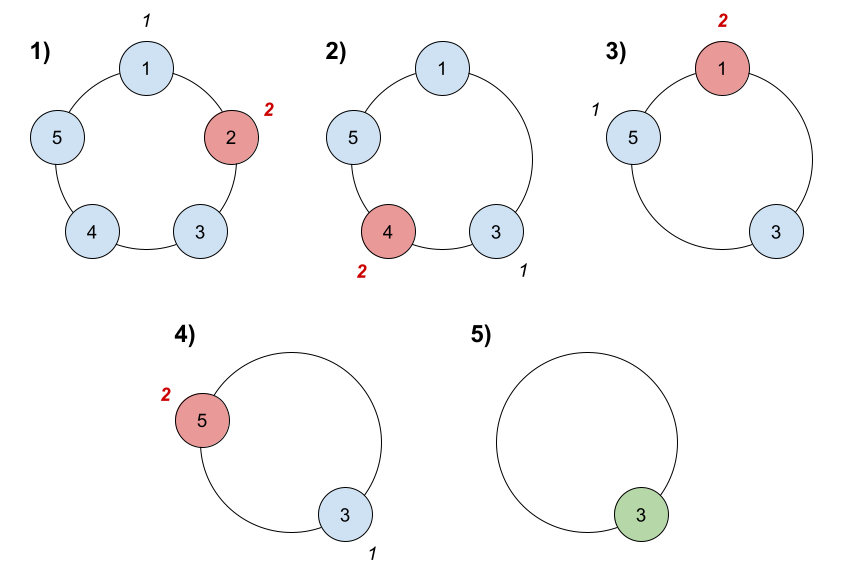

In [9]:
from queue import deque

def findTheWinner(n, k):
    q = deque()

    for i in range(1, n + 1):
        q.append(i)
    
    while len(q) > 1:
        for i in range(k - 1):
            num = q.popleft()
            q.append(num)

        q.popleft()
    
    return q[0]

In [10]:
assert findTheWinner(5, 2) == 3
assert findTheWinner(100, 3) == 91

In [ ]:
# DO NOT DELETE THIS CELL

In [ ]:
# DO NOT DELETE THIS CELL

---

# **Problem 4: Find the maxium number of positive or negatives (2)**

Given an array nums sorted in non-decreasing order, return the maximum between the number of positive integers and the number of negative integers.

In other words, if the number of positive integers in nums is pos and the number of negative integers is neg, then return the maximum of pos and neg.
Note that 0 is neither positive nor negative.
```
Input: nums = [-3,-2,-1,0,0,1,2]
Output: 3
```
```
Explanation: There are 2 positive integers and 3 negative integers. The maximum count among them is 3.
```

Your solution will be graded based on the time complexity. Here is the breakdown:

| Complexity                | Points |
|---------------------------|--------|
| $O(n)$                  | 1      |
| $O(log(n))$      | 2      |

In [13]:
def maximumCount(nums):
  """
  :type nums: List[int]
  :rtype: int
  """
  # Binary search for first positive number (>0)
  left, right = 0, len(nums) - 1
  while left <= right:
    mid = (left + right) // 2
    if nums[mid] <= 0:
      left = mid + 1
    else:
      right = mid - 1
  pos = len(nums) - left  # Count of positive numbers

  # Binary search for last negative number (<0) 
  left, right = 0, len(nums) - 1
  while left <= right:
    mid = (left + right) // 2
    if nums[mid] < 0:
      left = mid + 1
    else:
      right = mid - 1
  neg = left  # Count of negative numbers

  return max(pos, neg)


In [12]:
assert maximumCount([-3,-2,-1,0,0,1,2]) == 3
assert maximumCount([-2,-1,-1,1,2,3]) == 3

In [ ]:
# DO NOT DELETE THIS CODE

In [ ]:
# DO NOT DELETE THIS CODE

In [ ]:
# DO NOT DELETE THIS CODE

---

# **Problem 5: Mario (1)**

Mario is climbing a stair case to save princess and it takes n steps to reach the top. Each time Mario can either climb 1 or 2 steps. Write a recursive function count_ways(n) that returns the number of distinct ways he can climb to the top of the tower.

Constraints:  `1 <= n <= 30`

In [127]:
def count_ways(n: int, memo={}) -> int:
    if n == 1:
        return 1
    if n == 2:
        return 2
    else:
        return count_ways(n - 1) + count_ways(n - 2)

In [128]:
assert count_ways(1) == 1
assert count_ways(2) == 2
assert count_ways(4) == 5

In [ ]:
# DO NOT DELETE THIS CODE

In [ ]:
# DO NOT DELETE THIS CODE